# Titanic Data Analysis Project

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1. Import Libraries

In [3]:
# Import the required libraries
import pandas as pd
import numpy as np
import os

## 2. Load Dataset

In [4]:
file_path = "/content/drive/MyDrive/Titanic_Project/data/train.csv"
df = pd.read_csv(file_path)

In [5]:
# Check the uploaded files
os.listdir()

['.config', 'drive', 'sample_data']

## 3. Initial Exploration

In [6]:
# Display the first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Display the last five rows of the dataset
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
# Display the number of rows and columns
df.shape

(891, 12)

In [9]:
# Display the names of all columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [10]:
# Display information about the dataset
# (data types, non-null values, memory usage)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
# Display summary statistics for numerical columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
# Count the missing values in each column
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
# Count the number of duplicate rows
df.duplicated().sum()

np.int64(0)

## 4. Data Cleaning

In [14]:
# Remove the Cabin column because it contains many missing values
df.drop(columns=["Cabin"], inplace=True)

In [15]:
# Fill missing Age values with the median age
df["Age"] = df["Age"].fillna(df["Age"].median())

In [16]:
# Fill missing Embarked values with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [17]:
# Check that all missing values have been handled
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
# Save the cleaned dataset as a new CSV file
df.to_csv("titanic_cleaned.csv", index=False)

In [19]:
# Display each column's data type
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


## 5. Data Validation

In [20]:
# Check the unique categories in selected columns
print("Survived:", df["Survived"].unique())
print("Pclass:", df["Pclass"].unique())
print("Sex:", df["Sex"].unique())
print("Embarked:", df["Embarked"].unique())

Survived: [0 1]
Pclass: [3 1 2]
Sex: ['male' 'female']
Embarked: ['S' 'C' 'Q']


In [21]:
# Display minimum and maximum values for important numerical columns
print("Age range:", df["Age"].min(), "-", df["Age"].max())
print("Fare range:", df["Fare"].min(), "-", df["Fare"].max())
print("SibSp range:", df["SibSp"].min(), "-", df["SibSp"].max())
print("Parch range:", df["Parch"].min(), "-", df["Parch"].max())

Age range: 0.42 - 80.0
Fare range: 0.0 - 512.3292
SibSp range: 0 - 8
Parch range: 0 - 6


In [22]:
# Check for invalid negative values
print("Negative ages:", (df["Age"] < 0).sum())
print("Negative fares:", (df["Fare"] < 0).sum())

Negative ages: 0
Negative fares: 0


In [23]:
# Check whether PassengerId contains duplicate identifiers
df["PassengerId"].duplicated().sum()

np.int64(0)

In [24]:
# Remove leading and trailing spaces from text columns
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].str.strip()

In [25]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [26]:
# Final cleaning checks
print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate PassengerIds:", df["PassengerId"].duplicated().sum())

Dataset shape: (891, 11)
Total missing values: 0
Duplicate rows: 0
Duplicate PassengerIds: 0


In [27]:
# Save the final cleaned dataset
df.to_csv("Titanic_clean.csv", index=False)

## 6. Exploratory Data Analysis


In [28]:
# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [29]:
# Confirm that the cleaned dataset is loaded correctly
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [30]:
# Count passengers who survived and did not survive
survival_counts = df["Survived"].value_counts()
survival_counts

,count
Survived,
0,549
1,342


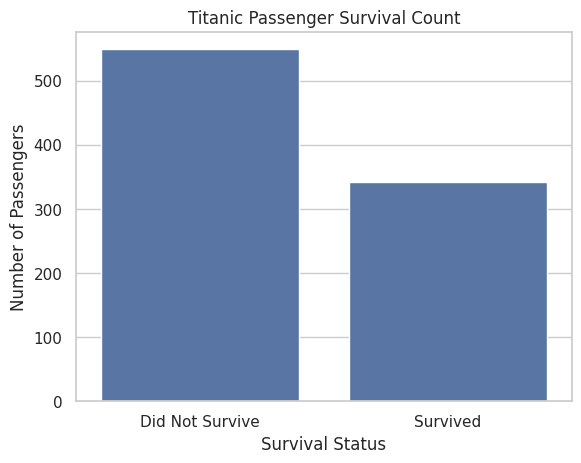

In [31]:
# Visualize the number of passengers by survival status
sns.countplot(data=df, x="Survived")

plt.title("Titanic Passenger Survival Count")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.show()

In [32]:
# Calculate the percentage of passengers in each survival category
survival_percentages = df["Survived"].value_counts(normalize=True) * 100
survival_percentages

,proportion
Survived,
0,61.616162
1,38.383838


In [33]:
# Calculate the overall survival rate
overall_survival_rate = df["Survived"].mean() * 100

print(f"Overall survival rate: {overall_survival_rate:.2f}%")

Overall survival rate: 38.38%


### Finding

The dataset contains more passengers who did not survive than passengers who survived. The overall survival rate was approximately 38.38%.

In [34]:
# Calculate survival percentage for each sex
survival_by_sex = df.groupby("Sex")["Survived"].mean() * 100
survival_by_sex

,Survived
Sex,
female,74.203822
male,18.890815


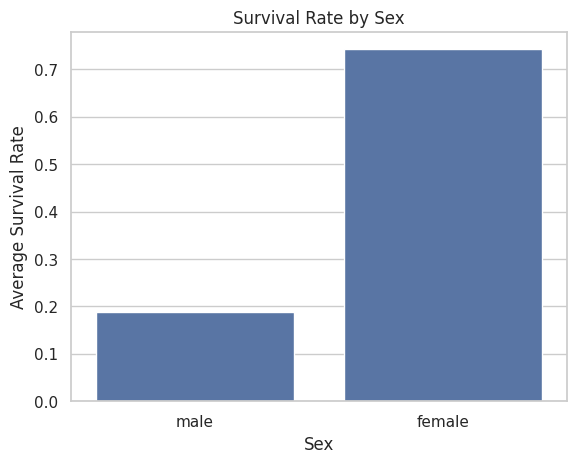

In [35]:
# Visualize survival rate by sex
sns.barplot(data=df, x="Sex", y="Survived", errorbar=None)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.show()

### Finding

Female passengers had a considerably higher survival rate than male passengers. This shows a strong association between sex and survival.

In [36]:
# Calculate survival percentage for each passenger class
survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100
survival_by_class

,Survived
Pclass,
1,62.962963
2,47.282609
3,24.236253


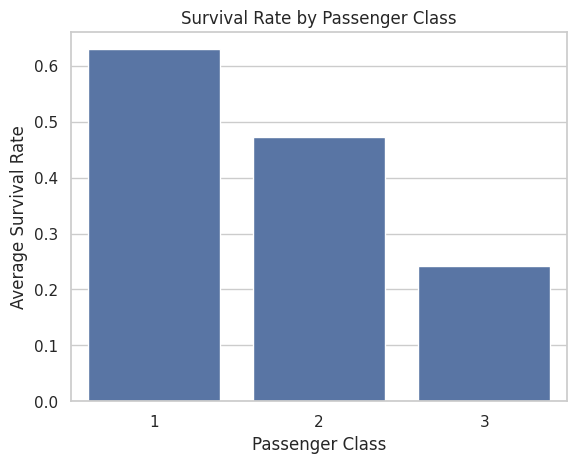

In [37]:
# Visualize survival rate by passenger class
sns.barplot(data=df, x="Pclass", y="Survived", errorbar=None)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Survival Rate")
plt.show()

### Finding

First-class passengers had the highest survival rate, while third-class passengers had the lowest. Passenger class was therefore strongly associated with survival.

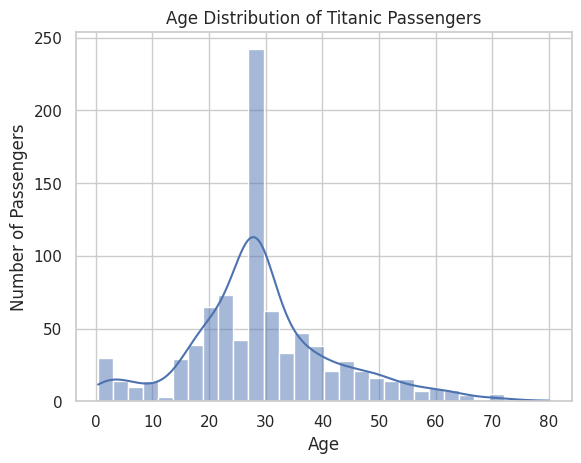

In [38]:
# Visualize the distribution of passenger ages
sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

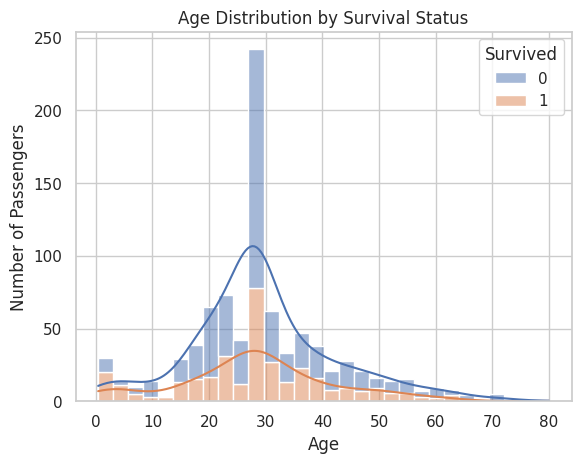

In [39]:
# Compare age distributions for survivors and non-survivors
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

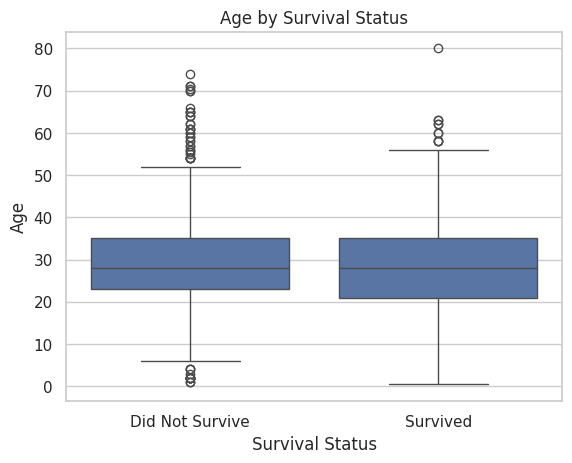

In [40]:
# Compare age distributions using a box plot
sns.boxplot(data=df, x="Survived", y="Age")

plt.title("Age by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.show()

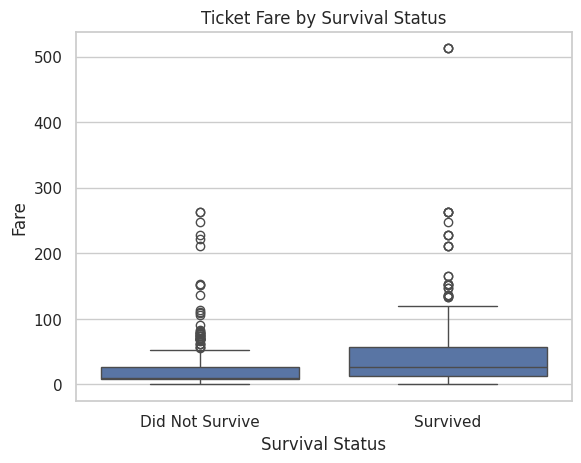

In [41]:
# Compare ticket fares between survivors and non-survivors
sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Ticket Fare by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.show()

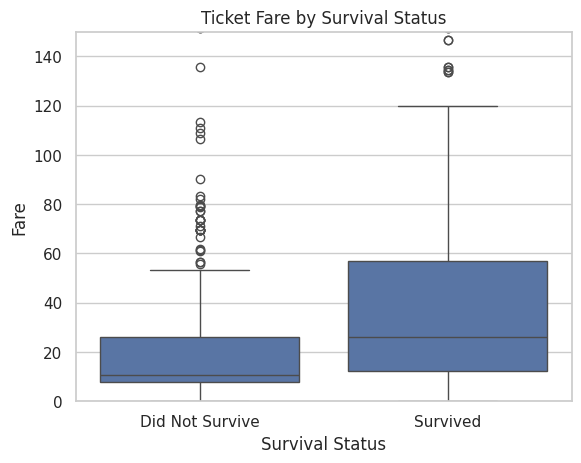

In [42]:
# Limit the visible range to make the main distribution easier to read
sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Ticket Fare by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])
plt.ylim(0, 150)
plt.show()

In [43]:
# Calculate survival percentage by embarkation port
survival_by_embarked = df.groupby("Embarked")["Survived"].mean() * 100
survival_by_embarked

,Survived
Embarked,
C,55.357143
Q,38.961039
S,33.900929


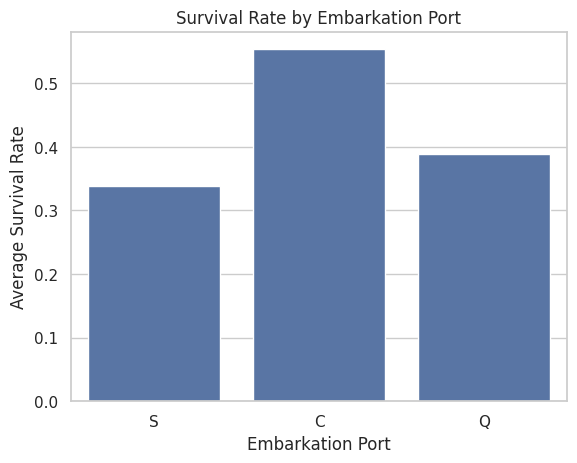

In [44]:
# Visualize survival rate by embarkation port
sns.barplot(data=df, x="Embarked", y="Survived", errorbar=None)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Average Survival Rate")
plt.show()

C = Cherbourg
Q = Queenstown
S = Southampton

### Finding

Passengers who embarked from different ports had different survival rates. In particular, passengers who boarded at Cherbourg showed a higher survival rate than those who boarded at Southampton or Queenstown. This indicates an association between embarkation port and survival.

In [45]:
# Create a new feature representing total family members aboard
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [46]:
# Display the number of passengers for each family size
df["FamilySize"].value_counts().sort_index()

,count
FamilySize,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


In [47]:
# Calculate survival percentage by family size
survival_by_family_size = (
    df.groupby("FamilySize")["Survived"].mean() * 100
)

survival_by_family_size

,Survived
FamilySize,
1,30.353818
2,55.279503
3,57.843137
4,72.413793
5,20.000000
6,13.636364
7,33.333333
8,0.000000
11,0.000000


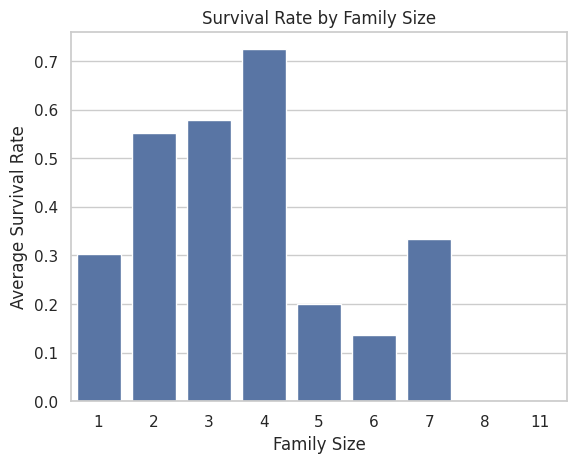

In [48]:
# Visualize survival rate by family size
sns.barplot(data=df, x="FamilySize", y="Survived", errorbar=None)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")
plt.show()

In [49]:
# Select numerical features for correlation analysis
selected_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

correlation_matrix = df[selected_columns].corr()
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,0.065997
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,-0.245619
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.217138
FamilySize,0.016639,0.065997,-0.245619,0.890712,0.783111,0.217138,1.000000


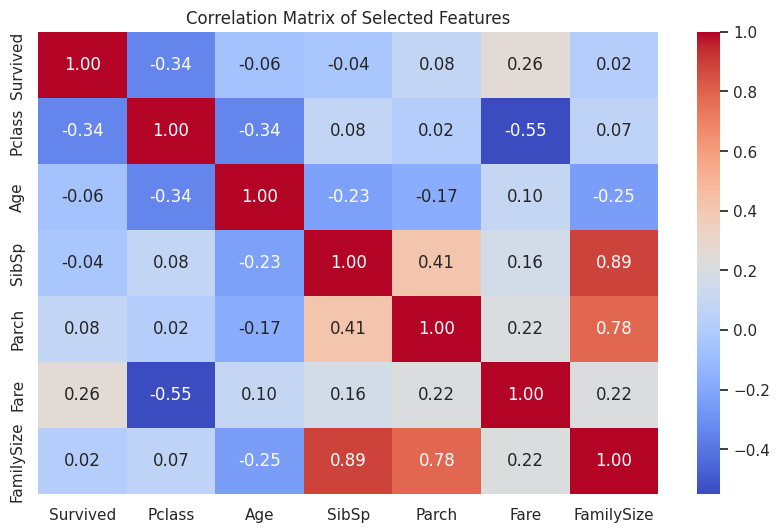

In [50]:
# Visualize correlations between selected numerical features
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Selected Features")
plt.show()

In [51]:
# Save the cleaned and feature-engineered dataset to Google Drive
output_path = (
    "/content/drive/MyDrive/Titanic_Project/data/"
    "Titanic_clean_with_features.csv"
)

df.to_csv(output_path, index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


## 7. Machine Learning

### 7.1 Logistic Regression

In [52]:
# Import machine learning tools

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [53]:
# Select the features we want the model to use

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize"
]

X = df[features]

# Target variable
y = df["Survived"]

In [54]:
# Numerical features
numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize"
]

# Categorical features
categorical_features = [
    "Sex",
    "Embarked"
]

In [55]:
# Preprocess numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [56]:
# Create a pipeline that preprocesses the data
# and then trains Logistic Regression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [57]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [58]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 8)
X_test: (179, 8)
y_train: (712,)
y_test: (179,)


In [59]:
# Train the Logistic Regression model

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [60]:
# Predict survival for the test data

y_pred = model.predict(X_test)

In [61]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 80.45%


In [62]:
# Display precision, recall, F1-score and support

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [63]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[98, 12],
       [23, 46]])

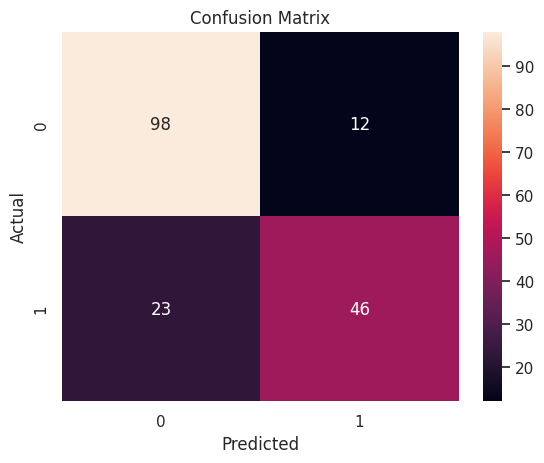

In [64]:
# Visualize the confusion matrix

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.2 Decision Tree

In [65]:
# Import the Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

In [66]:
# Create the Decision Tree pipeline

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [67]:
# Train the Decision Tree model

decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [68]:
# Make predictions using the Decision Tree

y_pred_tree = decision_tree_model.predict(X_test)

In [69]:
# Calculate Decision Tree accuracy

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(f"Decision Tree Accuracy: {tree_accuracy:.2%}")

Decision Tree Accuracy: 77.65%


In [70]:
# Display Decision Tree classification report

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.72      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



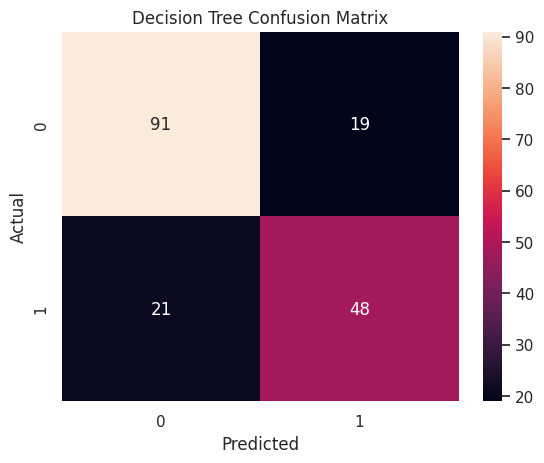

In [71]:
# Create Decision Tree confusion matrix

tree_cm = confusion_matrix(y_test, y_pred_tree)

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.3 Random Forest

In [72]:
# Import Random Forest classifier

from sklearn.ensemble import RandomForestClassifier

In [73]:
# Create the Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [74]:
# Train the Random Forest model

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare',
                                                   'FamilySize']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [75]:
# Make predictions using Random Forest

y_pred_forest = random_forest_model.predict(X_test)

In [76]:
# Calculate Random Forest accuracy

forest_accuracy = accuracy_score(y_test, y_pred_forest)

print(f"Random Forest Accuracy: {forest_accuracy:.2%}")

Random Forest Accuracy: 81.56%


In [77]:
# Display Random Forest classification report

print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



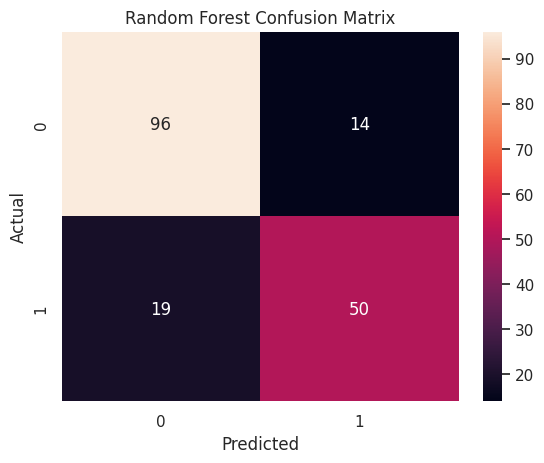

In [78]:
# Create Random Forest confusion matrix

forest_cm = confusion_matrix(y_test, y_pred_forest)

sns.heatmap(
    forest_cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.4 Model Comparison

In [79]:
# Compare model accuracies

print(f"Logistic Regression: {accuracy:.2%}")
print(f"Decision Tree:       {tree_accuracy:.2%}")
print(f"Random Forest:       {forest_accuracy:.2%}")

Logistic Regression: 80.45%
Decision Tree:       77.65%
Random Forest:       81.56%


In [80]:
# Create a model comparison table

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.776536
2,Random Forest,0.815642


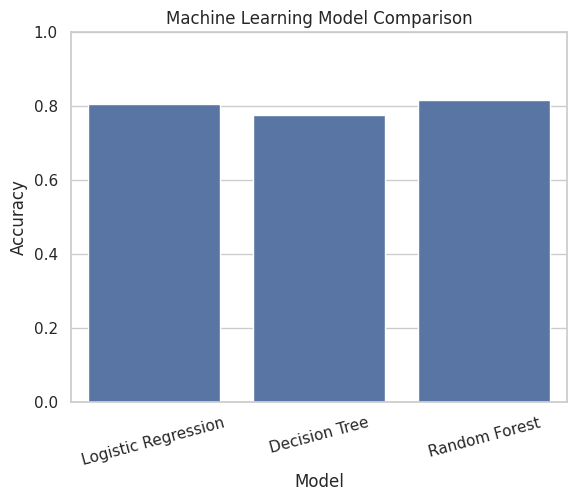

In [81]:
# Visualize model accuracy comparison

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

### Model Comparison Finding

Three classification models were evaluated on the same test dataset. Random Forest achieved the highest accuracy at 81.56%, followed by Logistic Regression at 80.45%, while Decision Tree achieved 77.65%. Based on accuracy, Random Forest was the best-performing model, although its improvement over Logistic Regression was relatively small.

In [82]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409
1,Decision Tree,0.776536,0.716418,0.695652,0.705882
2,Random Forest,0.815642,0.781250,0.724638,0.751880


## Model Comparison

Three machine learning models were trained and evaluated on the Titanic dataset.

- Logistic Regression achieved an accuracy of **80.45%**.
- Decision Tree achieved an accuracy of **77.65%**.
- Random Forest achieved the highest accuracy of **81.56%**.

Random Forest also produced the highest recall and F1-score, making it the best-performing model in this project. Although Logistic Regression achieved slightly higher precision, Random Forest provided the best overall balance between accuracy, recall, and F1-score.